<a href="https://colab.research.google.com/github/mz852608/Google-Colab/blob/main/transformasi_grayscale_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-566928096.py:19: RuntimeWarning: overflow encountered in scalar add
  c = 255 / np.log(1 + np.max(img))
/tmp/ipython-input-566928096.py:19: RuntimeWarning: divide by zero encountered in log
  c = 255 / np.log(1 + np.max(img))


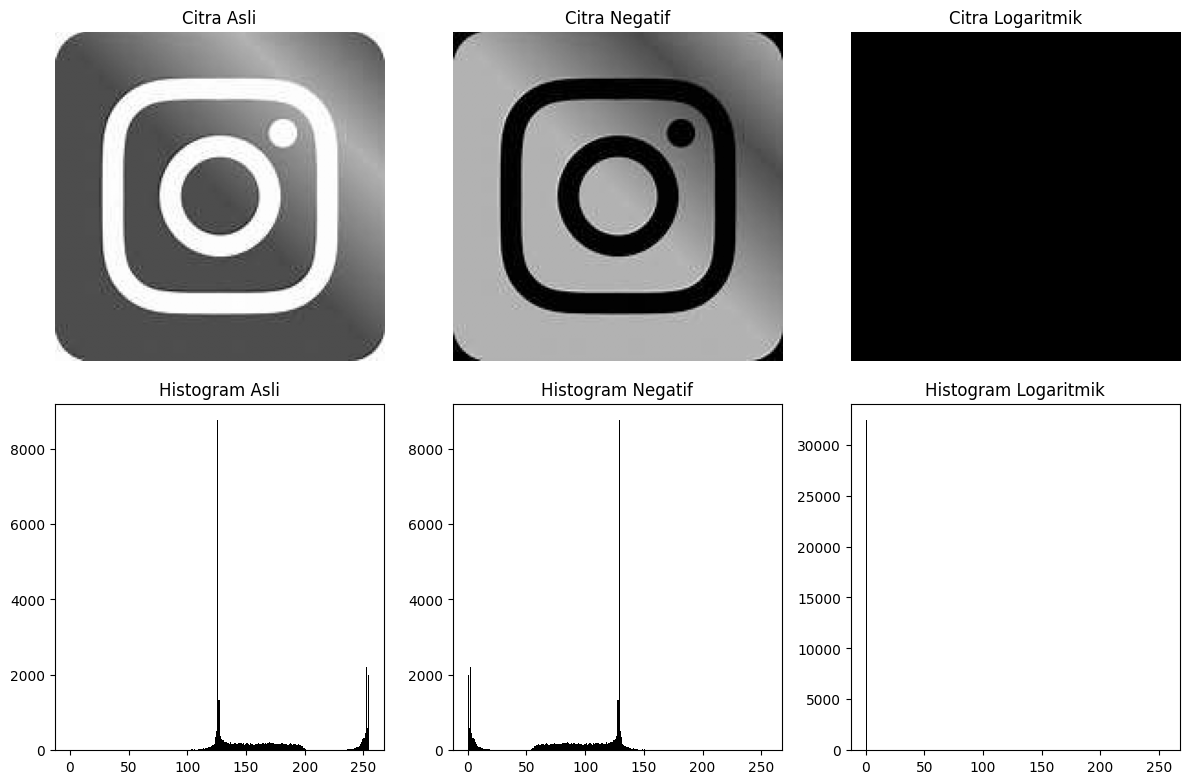

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# === 1. Baca satu citra grayscale (.jpg / .png) ===
# Ganti nama file sesuai gambar kamu
img = cv2.imread("OIP.jpg", cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError("File 'gambar.jpg' tidak ditemukan. Pastikan file ada di folder yang sama!")

# === 2. Transformasi Negatif ===
# Rumus: G = 255 - Fhttps://id.images.search.yahoo.com/images/view;_ylt=Awrx.GLOJBRp8UMFxyTNQwx.;_ylu=c2VjA3NyBHNsawNpbWcEb2lkAzNlZGNkMzZiNWJjNzdiNGU2MDAxMDgyZjBjYTQ0NDk1BGdwb3MDNzIEaXQDYmluZw--?back=https%3A%2F%2Fid.images.search.yahoo.com%2Fsearch%2Fimages%3Fp%3DKumpulan%2Bgrayscale%2Bgambar%2Bjpg%2Bdan%2Bpng%26ei%3DUTF-8%26type%3DE210ID91215G0%26fr%3Dmcafee%26fr2%3Dp%253As%252Cv%253Ai%252Cm%253Asb-top%26nost%3D1%26tab%3Dorganic%26ri%3D72&w=640&h=640&imgurl=png.pngtree.com%2Fpng-vector%2F20210313%2Fourlarge%2Fpngtree-vector-design-grayscale-mosque-png-image_3048703.png&rurl=https%3A%2F%2Fid.pngtree.com%2Ffreepng%2Fvector-design-grayscale-mosque_6100896.html&size=31KB&p=Kumpulan+grayscale+gambar+jpg+dan+png&oid=3edcd36b5bc77b4e6001082f0ca44495&fr2=p%3As%2Cv%3Ai%2Cm%3Asb-top&fr=mcafee&tt=Gambar+Vektor+Desain+Masjid+Grayscale%2C+Abu+Abu%2C+Vektor%2C+Mesjid+PNG+dan+...&b=61&ni=56&no=72&ts=&tab=organic&sigr=8vA2prBCNWN.&sigb=OT.bpoxTEUL.&sigi=lXyeucNpxnzC&sigt=LW9MPGRgzbiZ&.crumb=4zZKVQaCBuX&fr=mcafee&fr2=p%3As%2Cv%3Ai%2Cm%3Asb-top&type=E210ID91215G0
negatif = 255 - img

# === 3. Transformasi Logaritmik ===
# Rumus: G = c * log(1 + F)
# dengan c = 255 / log(1 + max(F))
c = 255 / np.log(1 + np.max(img))
logaritmik = c * np.log(1 + img.astype(np.float64))
logaritmik = np.array(logaritmik, dtype=np.uint8)

# === 4. Tampilkan keempat gambar dan histogram masing-masing ===
plt.figure(figsize=(12, 8))

# Citra asli
plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title("Citra Asli")
plt.axis('off')

plt.subplot(2, 3, 4)
plt.hist(img.ravel(), bins=256, range=(0, 255), color='black')
plt.title("Histogram Asli")

# Citra negatif
plt.subplot(2, 3, 2)
plt.imshow(negatif, cmap='gray')
plt.title("Citra Negatif")
plt.axis('off')

plt.subplot(2, 3, 5)
plt.hist(negatif.ravel(), bins=256, range=(0, 255), color='black')
plt.title("Histogram Negatif")

# Citra logaritmik
plt.subplot(2, 3, 3)
plt.imshow(logaritmik, cmap='gray')
plt.title("Citra Logaritmik")
plt.axis('off')

plt.subplot(2, 3, 6)
plt.hist(logaritmik.ravel(), bins=256, range=(0, 255), color='black')
plt.title("Histogram Logaritmik")

plt.tight_layout()
plt.show()




Text(0.5, 1.0, 'Low Pa')

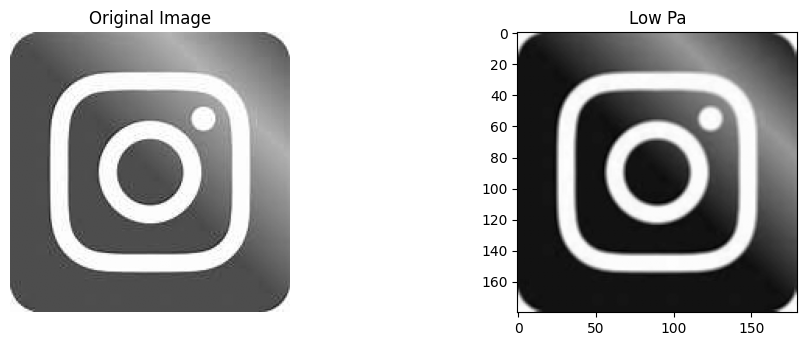

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1️⃣ Baca gambar grayscale
img = cv2.imread('OIP.jpg', cv2.IMREAD_GRAYSCALE)

# 2️⃣ Definisikan kernel filter
kernel_LPF = (1/9) * np.array([[1,1,1],
                               [1,1,1],
                               [1,1,1]])

kernel_HPF = np.array([[-1,-1,-1],
                       [-1, 8,-1],
                       [-1,-1,-1]])

kernel_BPF = np.array([[0,-1,0],
                       [-1,5,-1],
                       [0,-1,0]])

# 3️⃣ Terapkan konvolusi (filtering)
img_LPF = cv2.filter2D(img, -1, kernel_LPF)
img_HPF = cv2.filter2D(img, -1, kernel_HPF)
img_BPF = cv2.filter2D(img, -1, kernel_BPF)

# 4️⃣ Tampilkan hasil dalam satu figure
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(img_LPF, cmap='gray')
plt.title('Low Pa')

